# Member 2 — Regression Models, Evaluation, Tuning, CV, Diagnostics

Input: preprocessed train/test split from Member 1 (`data/processed/regression_train.csv`, `regression_test.csv`).
Scope: 10 regression algorithms, comparison table, GridSearchCV on 2 best models, 5-fold CV, residual/pred-vs-actual
and feature-importance diagnostics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8')
sns.set_palette('tab10')

## 1. Load preprocessed split (owned by Member 1)

Dataset: `data/airquality/AirQualityUCI.csv` (UCI Air Quality). Target: `CO(GT)` — this is the target
Member 1's EDA/preprocessing notebook settled on (`NMHC(GT)` dropped for ~90% missingness; `CO(GT)`
chosen over `C6H6(GT)` after the dataset audit). `-200` is the dataset's missing-value sentinel.

Tries Member 1's cleaned/split CSVs first; falls back to a raw loader with a placeholder impute so this
notebook is not blocked on their output landing.

In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split

TARGET = 'CO(GT)'
PROCESSED_TRAIN = Path('../data/processed/regression_train.csv')
PROCESSED_TEST = Path('../data/processed/regression_test.csv')

if PROCESSED_TRAIN.exists() and PROCESSED_TEST.exists():
    train_df = pd.read_csv(PROCESSED_TRAIN)
    test_df = pd.read_csv(PROCESSED_TEST)
else:
    print('data/processed split not found — using raw-loader fallback')
    raw = pd.read_csv('../data/airquality/AirQualityUCI.csv', sep=';', decimal=',')
    raw = raw.loc[:, ~raw.columns.str.contains('^Unnamed')].dropna(how='all')
    raw = raw.drop(columns=['Date', 'Time', 'NMHC(GT)'])  # NMHC(GT) ~90% missing, unusable
    raw = raw.replace(-200, np.nan)
    raw = raw.dropna(subset=[TARGET])  # can't train/eval without target
    raw = raw.fillna(raw.median(numeric_only=True))  # placeholder impute; Member 1 owns final strategy
    train_df, test_df = train_test_split(raw, test_size=0.2, random_state=RANDOM_STATE)

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]
X_train.shape, X_test.shape

((6138, 12), (1535, 12))

## 2. Define all 10 models

Built up incrementally, one algorithm family per commit.

In [3]:
models = {}

In [4]:
models.update({
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=RANDOM_STATE),
    'ElasticNet Regression': ElasticNet(random_state=RANDOM_STATE),
})
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression']

In [5]:
models['Polynomial Regression'] = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lin', LinearRegression())
])
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression']

In [6]:
models['Decision Tree Regressor'] = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor']

In [7]:
models['Random Forest Regressor'] = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor']

In [8]:
models['Gradient Boosting Regressor'] = GradientBoostingRegressor(random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor']

In [9]:
models['SVR'] = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(C=1.0, kernel='rbf'))
])
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor',
 'SVR']

In [10]:
models['KNN Regressor'] = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])
len(models)

10

## 3. Train all models, generate predictions

In [11]:
predictions = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    fitted_models[name] = model

list(predictions.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor',
 'SVR',
 'KNN Regressor']

## 4. Comparison table — R2, RMSE, MAE, ranked

In [12]:
rows = []
for name, y_pred in predictions.items():
    rows.append({
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
    })

results_df = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.914282,0.426862,0.266479
1,SVR,0.912053,0.432376,0.255644
2,KNN Regressor,0.909990,0.437418,0.274046
3,Gradient Boosting Regressor,0.907572,0.443255,0.280931
4,Polynomial Regression,0.903601,0.452676,0.290625
5,Decision Tree Regressor,0.873198,0.519176,0.354305
6,Linear Regression,0.858312,0.548806,0.344436
7,Ridge Regression,0.858310,0.548809,0.344401
8,ElasticNet Regression,0.636292,0.879282,0.622257
9,Lasso Regression,0.304941,1.215522,0.920124


## 5. Hyperparameter tuning — GridSearchCV on top 2 models

In [13]:
top2 = results_df['Model'].head(2).tolist()
print('Tuning:', top2)

param_grids = {
    'Random Forest Regressor': {
        'n_estimators': [100, 200, 400],
        'max_depth': [None, 5, 10, 20],
    },
    'Gradient Boosting Regressor': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4],
    },
    'SVR': {
        'svr__C': [0.1, 1, 10],
        'svr__kernel': ['rbf', 'linear'],
    },
    'KNN Regressor': {
        'knn__n_neighbors': [3, 5, 7, 9, 11],
    },
    'Ridge Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso Regression': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
    'ElasticNet Regression': {'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.1, 0.5, 0.9]},
    'Decision Tree Regressor': {'max_depth': [3, 5, 7, 10, None]},
}

tuned_results = {}
for name in top2:
    grid = param_grids.get(name)
    if grid is None:
        print(f'No grid defined for {name}, skipping tuning')
        continue
    gs = GridSearchCV(models[name], grid, scoring='r2', cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_pred = gs.best_estimator_.predict(X_test)
    tuned_results[name] = {
        'best_params': gs.best_params_,
        'best_cv_r2': gs.best_score_,
        'test_r2_before': results_df.set_index('Model').loc[name, 'R2'],
        'test_r2_after': r2_score(y_test, tuned_pred),
    }
    fitted_models[name] = gs.best_estimator_

pd.DataFrame(tuned_results).T

Tuning: ['Random Forest Regressor', 'SVR']


,best_params,best_cv_r2,test_r2_before,test_r2_after
Random Forest Regressor,"{'max_depth': None, 'n_estimators': 400}",0.911504,0.914282,0.914873
SVR,"{'svr__C': 10, 'svr__kernel': 'rbf'}",0.918714,0.912053,0.92061


## 6. 5-fold cross-validated R2 for top 2 models

In [14]:
cv_rows = []
for name in top2:
    scores = cross_val_score(fitted_models[name], X_train, y_train, cv=5, scoring='r2')
    cv_rows.append({'Model': name, 'CV R2 mean': scores.mean(), 'CV R2 std': scores.std()})

pd.DataFrame(cv_rows)

,Model,CV R2 mean,CV R2 std
0,Random Forest Regressor,0.911504,0.006265
1,SVR,0.918714,0.007463


## 7. Diagnostics — residual plot, predicted-vs-actual, feature importance

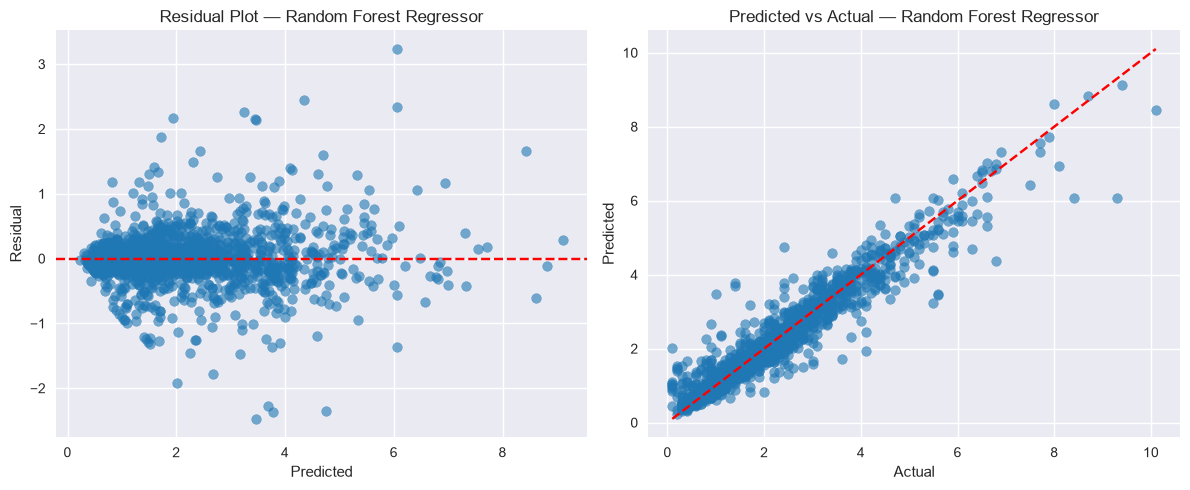

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_pred = fitted_models[best_model_name].predict(X_test)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(best_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residual Plot — {best_model_name}')

axes[1].scatter(y_test, best_pred, alpha=0.6)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Predicted vs Actual — {best_model_name}')

plt.tight_layout()
plt.savefig('../models/regression_diagnostics.png', bbox_inches='tight')
plt.show()

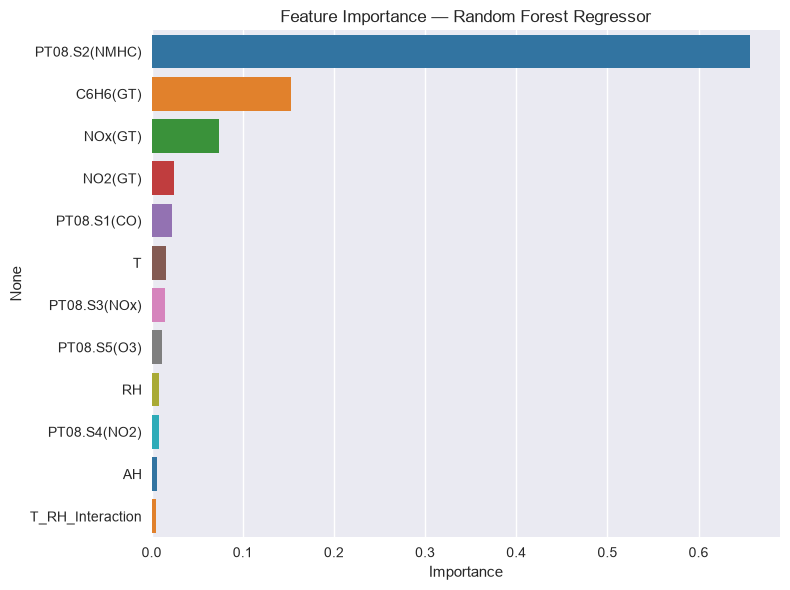

In [16]:
tree_model_name = 'Random Forest Regressor'
tree_model = fitted_models[tree_model_name]
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='tab10', legend=False)
plt.xlabel('Importance')
plt.title(f'Feature Importance — {tree_model_name}')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Save fitted models (optional, for app/ later)

In [17]:
import joblib
for name, model in fitted_models.items():
    fname = '../models/' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, fname, compress=3)